# 📱 Second-Hand Mobile Price Analyzer
## Member 4: GRU Model + Data Labeling + Data Support

**Project:** Second-Hand Mobile Price Analyzer  
**Role:** Member 4 — GRU Model, Labeling Logic, Data Cleaning Support  
**Dataset:** OLX-scraped Egyptian mobile listings (5544 entries)  

---

### 🗺️ Notebook Structure
| Part | Description |
|------|-------------|
| 1 | Data Loading & Cleaning |
| 2 | Labeling Logic (Core Task) |
| 3 | Text Processing Pipeline |
| 4 | GRU Model Architecture |
| 5 | Training & Evaluation (GRU) |
| 6 | Build & Train LSTM Model |
| 7 | GRU vs LSTM: Full Comparison |
| 8 | Data Support for Team |

---
## ⚙️ Environment Setup & Imports

In [1]:
# !pip install tensorflow scikit-learn pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, pickle, json, os, time, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, GRU, LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'✅ All imports successful')
print(f'TensorFlow version: {tf.__version__}')

✅ All imports successful
TensorFlow version: 2.20.0


---
## 📂 PART 1 — Data Loading & Cleaning

We start by loading the scraped dataset from OLX Egypt. The dataset contains 5544 mobile listings with:
- `price` — listing price (string, e.g., '5,500 EGP')
- `description` — seller's Arabic/Franco/English text
- `image_url` — URL of the phone image
- `listing_url` — URL of the listing
- `scraped_at` — timestamp

Our cleaning steps:
1. Parse and normalize the price column to a numeric value
2. Drop null / invalid rows
3. Normalize Arabic text (remove diacritics, normalize letters)
4. Remove emojis, HTML, special characters
5. Handle Franco-Arabic (transliterated Arabic written in English letters) — kept as-is since the GRU learns from context

In [2]:
# ── 1.1  Load the dataset ──────────────────────────────────────────────────
# Update the path below to match where your CSV is located
DATA_PATH = '/content/mobile_phones.csv'   # ← change if needed

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (5544, 5)


,price,description,image_url,listing_url,scraped_at
0,"EGP 6,900",آيفون اكس آر,https://images.dubizzle.com.eg/thumbnails/1711...,https://www.dubizzle.com.eg/en/ad/%D8%A2%D9%8A...,2026-05-03T15:23:55.965589+00:00
1,"EGP 10,500",آيفون اكس إس ماكس 256 مغير بطاريه 100% وفاصل ف...,https://images.dubizzle.com.eg/thumbnails/1712...,https://www.dubizzle.com.eg/en/ad/%D8%A2%D9%8A...,2026-05-03T15:21:23.828196+00:00
2,"EGP 9,000",آيفون اكس ار احمر 128 معاه علبه وشاحن وجراب بد...,https://images.dubizzle.com.eg/thumbnails/1710...,https://www.dubizzle.com.eg/en/ad/%D8%A2%D9%8A...,2026-05-03T15:25:46.598083+00:00


In [3]:
# ── 1.2  Basic info & null check ──────────────────────────────────────────
print(df.dtypes)
print('\nNull counts:')
print(df.isnull().sum())

price          object
description    object
image_url      object
listing_url    object
scraped_at     object
dtype: object

Null counts:
price          0
description    0
image_url      0
listing_url    0
scraped_at     0
dtype: int64


In [4]:
# ── 1.3  Parse price column → numeric (EGP) ───────────────────────────────
def parse_price(raw):
    """
    Convert price strings like '5,500 EGP', '١٢٠٠٠', '12000 جنيه' → float.
    Returns NaN if conversion fails.
    """
    if pd.isna(raw):
        return np.nan

    raw = str(raw)

    # Convert Arabic-Indic numerals → Western
    arabic_digits = '٠١٢٣٤٥٦٧٨٩'
    western_digits = '0123456789'
    for a, w in zip(arabic_digits, western_digits):
        raw = raw.replace(a, w)

    # Remove everything that is not a digit or decimal separator
    raw = re.sub(r'[^\d.]', '', raw.replace(',', ''))

    try:
        value = float(raw)
        # Sanity filter: phones between 500 and 200,000 EGP
        return value if 500 <= value <= 200_000 else np.nan
    except ValueError:
        return np.nan


df['price_egp'] = df['price'].apply(parse_price)

print(f'Rows before price cleaning : {len(df)}')
df.dropna(subset=['price_egp'], inplace=True)
print(f'Rows after  price cleaning : {len(df)}')
df['price_egp'].describe()

Rows before price cleaning : 5544
Rows after  price cleaning : 5495


,price_egp
count,5495.000000
mean,19487.277707
std,20804.836171
min,500.000000
25%,6000.000000
50%,12500.000000
75%,25000.000000
max,195000.000000


In [5]:
# ── 1.4  Drop rows with missing descriptions ──────────────────────────────
df.dropna(subset=['description'], inplace=True)
df = df[df['description'].str.strip().str.len() > 5]   # keep meaningful text
df.reset_index(drop=True, inplace=True)
print(f'Rows after description cleaning: {len(df)}')

Rows after description cleaning: 5363


In [6]:
# ── 1.5  Text cleaning function ───────────────────────────────────────────

def normalize_arabic(text):
    """Normalize common Arabic letter variants."""
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ـ', '', text)          # tatweel
    # Remove Arabic diacritics (tashkeel)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    return text


def remove_emojis(text):
    """Remove emoji and non-BMP characters."""
    emoji_pattern = re.compile(
        '['
        u'\U0001F600-\U0001F64F'
        u'\U0001F300-\U0001F5FF'
        u'\U0001F680-\U0001F6FF'
        u'\U0001F1E0-\U0001F1FF'
        u'\U00002702-\U000027B0'
        u'\U000024C2-\U0001F251'
        ']+', flags=re.UNICODE)
    return emoji_pattern.sub('', text)


def clean_text(text):
    """
    Full cleaning pipeline for Arabic/Franco/English listing descriptions.
    """
    if pd.isna(text):
        return ''

    text = str(text)
    text = text.lower()
    text = remove_emojis(text)
    text = re.sub(r'<[^>]+>', ' ', text)          # HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)  # URLs
    text = normalize_arabic(text)

    # Keep Arabic letters, Latin letters, and digits — remove everything else
    text = re.sub(r'[^\u0600-\u06FFa-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['clean_description'] = df['description'].apply(clean_text)

# Quick sanity check
print('Original  :', df['description'].iloc[0][:100])
print('Cleaned   :', df['clean_description'].iloc[0][:100])

Original  : آيفون اكس آر
Cleaned   : ايفون اكس ار


In [7]:
# ── 1.6  Drop rows where cleaning resulted in empty text ──────────────────
df = df[df['clean_description'].str.strip().str.len() > 5]
df.reset_index(drop=True, inplace=True)
print(f'Final clean dataset size: {len(df)}')
df[['price_egp', 'clean_description']].head(5)

Final clean dataset size: 5358


,price_egp,clean_description
0,6900.0,ايفون اكس ار
1,10500.0,ايفون اكس اس ماكس 256 مغير بطاريه 100 وفاصل في...
2,9000.0,ايفون اكس ار احمر 128 معاه علبه وشاحن وجراب بد...
3,10000.0,ايفون اكس ار
4,5500.0,ايفون اكس


---
## 🏷️ PART 2 — Labeling Logic (Core Task)

### Methodology

We classify each listing as one of three categories:

| Label | Meaning |
|---|---|
| `Good Deal` | Price is significantly below the market average — a bargain |
| `Fair` | Price is within a normal market range |
| `Overpriced` | Price is significantly above the market average |

### Statistical Approach
We use **IQR-based thresholds** (robust to outliers) as primary method.

**IQR Method (chosen):**
- Good Deal  : price < Q1 − 0.5 × IQR
- Overpriced : price > Q3 + 0.5 × IQR  
- Fair       : everything in between

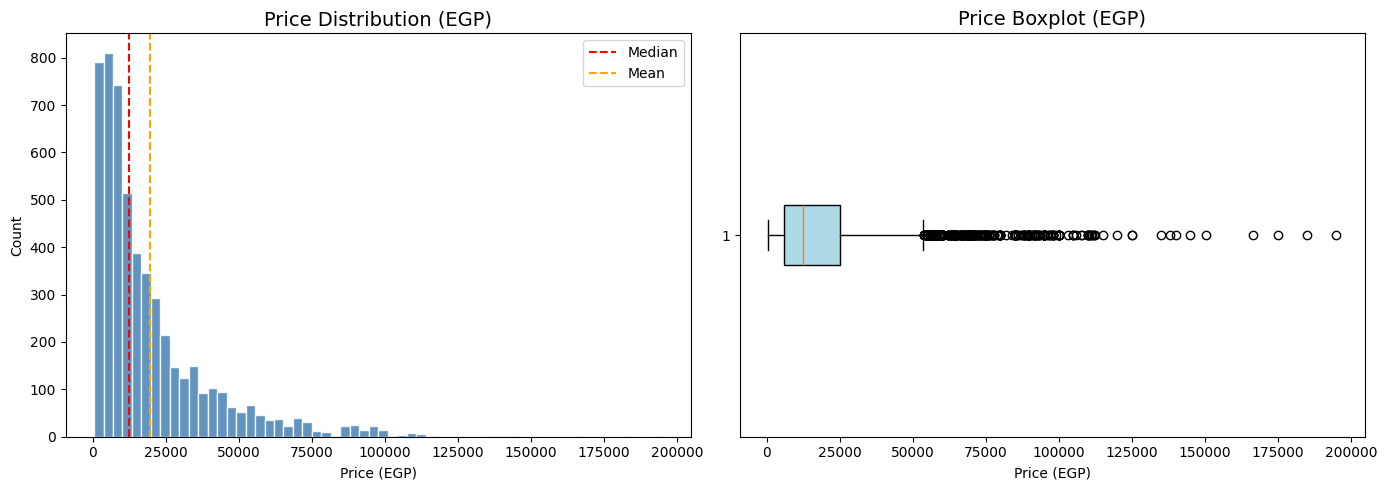

count       5358.000000
mean       19573.197275
std        20867.627588
min          500.000000
25%         6000.000000
50%        12500.000000
75%        25000.000000
max       195000.000000
median     12500.000000
IQR        19000.000000
Name: price_egp, dtype: float64


In [8]:
# ── 2.1  Price distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['price_egp'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (EGP)', fontsize=14)
axes[0].set_xlabel('Price (EGP)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price_egp'].median(), color='red', linestyle='--', label='Median')
axes[0].axvline(df['price_egp'].mean(), color='orange', linestyle='--', label='Mean')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['price_egp'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Price Boxplot (EGP)', fontsize=14)
axes[1].set_xlabel('Price (EGP)')

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

stats = df['price_egp'].describe()
stats['median'] = df['price_egp'].median()
stats['IQR'] = stats['75%'] - stats['25%']
print(stats)

In [9]:
# ── 2.2  Define IQR-based labeling thresholds ─────────────────────────────
Q1  = df['price_egp'].quantile(0.25)
Q3  = df['price_egp'].quantile(0.75)
IQR = Q3 - Q1

K = 0.5

LOWER_THRESHOLD = Q1 - K * IQR
UPPER_THRESHOLD = Q3 + K * IQR

print(f'Q1            : {Q1:,.0f} EGP')
print(f'Q3            : {Q3:,.0f} EGP')
print(f'IQR           : {IQR:,.0f} EGP')
print(f'Lower threshold (Good Deal  < ): {LOWER_THRESHOLD:,.0f} EGP')
print(f'Upper threshold (Overpriced > ): {UPPER_THRESHOLD:,.0f} EGP')

Q1            : 6,000 EGP
Q3            : 25,000 EGP
IQR           : 19,000 EGP
Lower threshold (Good Deal  < ): -3,500 EGP
Upper threshold (Overpriced > ): 34,500 EGP


In [10]:
# ── 2.3  Apply labeling ───────────────────────────────────────────────────
def label_price(price, lower=LOWER_THRESHOLD, upper=UPPER_THRESHOLD):
    if price < lower:
        return 'Good Deal'
    elif price > upper:
        return 'Overpriced'
    else:
        return 'Fair'

df['label'] = df['price_egp'].apply(label_price)

# ✅ FIX: Create label_int column needed by Parts 7
df['label_int'] = df['label'].map({'Good Deal': 0, 'Fair': 1, 'Overpriced': 2})

print('Label distribution:')
print(df['label'].value_counts())
print('\nPercentages:')
print(df['label'].value_counts(normalize=True).mul(100).round(1))

Label distribution:
label
Fair          4440
Overpriced     918
Name: count, dtype: int64

Percentages:
label
Fair          82.9
Overpriced    17.1
Name: proportion, dtype: float64


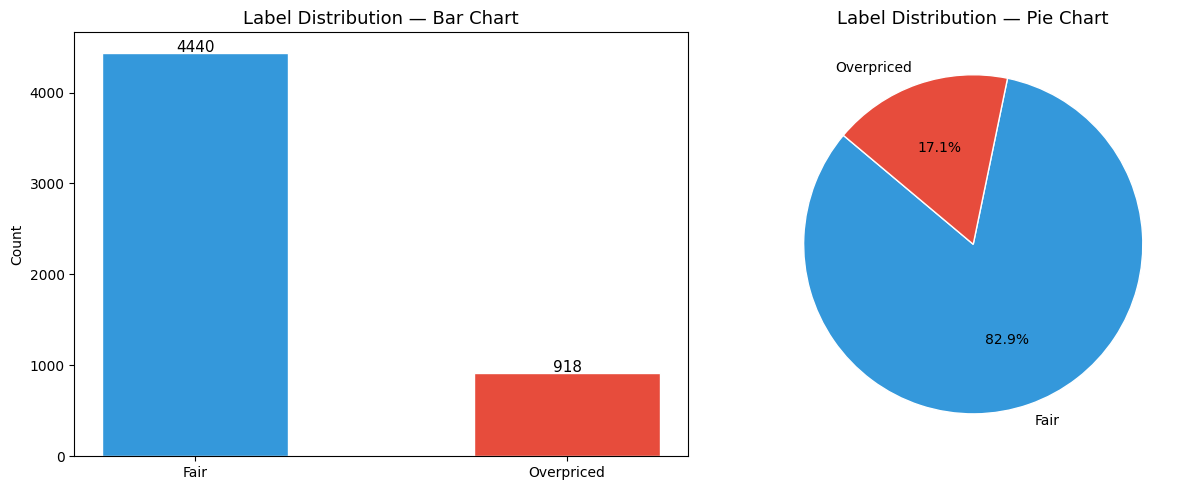

In [11]:
# ── 2.4  Visualize label distribution ────────────────────────────────────
label_counts = df['label'].value_counts()
colors = {'Good Deal': '#2ecc71', 'Fair': '#3498db', 'Overpriced': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(label_counts.index,
                   label_counts.values,
                   color=[colors[l] for l in label_counts.index],
                   edgecolor='white', width=0.5)
axes[0].set_title('Label Distribution — Bar Chart', fontsize=13)
axes[0].set_ylabel('Count')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10,
                 str(bar.get_height()), ha='center', fontsize=11)

axes[1].pie(label_counts.values,
            labels=label_counts.index,
            autopct='%1.1f%%',
            colors=[colors[l] for l in label_counts.index],
            startangle=140, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Label Distribution — Pie Chart', fontsize=13)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

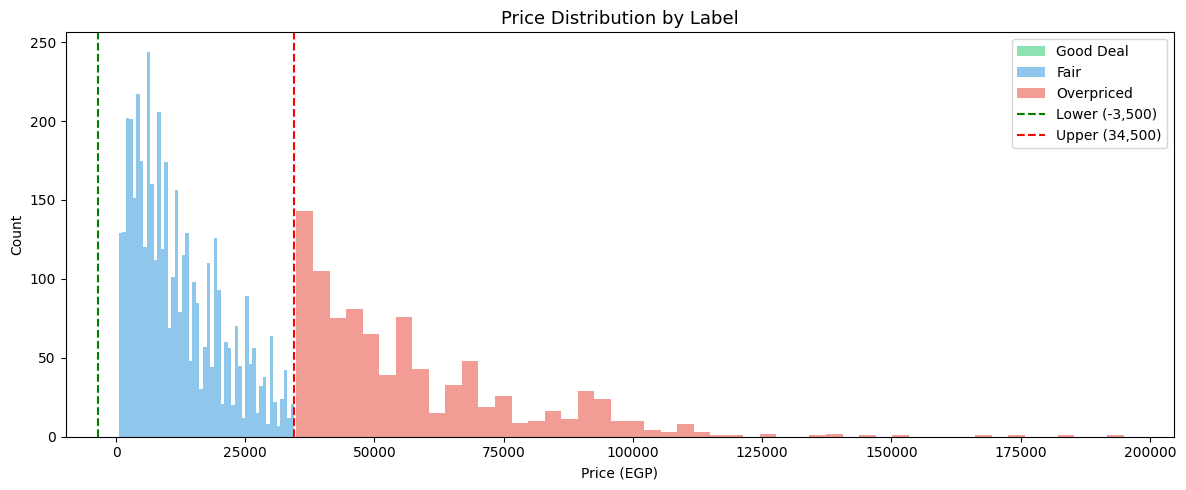

In [12]:
# ── 2.5  Price distribution per label (overlapping histograms) ────────────
fig, ax = plt.subplots(figsize=(12, 5))

for label, color in colors.items():
    subset = df[df['label'] == label]['price_egp']
    ax.hist(subset, bins=50, alpha=0.55, color=color, label=label, edgecolor='none')

ax.axvline(LOWER_THRESHOLD, color='green',  linestyle='--', linewidth=1.5, label=f'Lower ({LOWER_THRESHOLD:,.0f})')
ax.axvline(UPPER_THRESHOLD, color='red',    linestyle='--', linewidth=1.5, label=f'Upper ({UPPER_THRESHOLD:,.0f})')
ax.set_title('Price Distribution by Label', fontsize=13)
ax.set_xlabel('Price (EGP)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('price_by_label.png', dpi=150, bbox_inches='tight')
plt.show()

Brand frequency:
brand
Other      3543
Iphone      947
Samsung     326
Oppo        172
Redmi        90
Vivo         79
Realme       63
Huawei       33
Xiaomi       32
Infinix      26
Oneplus      22
Nokia        13
Tecno        11
Apple         1
Name: count, dtype: int64


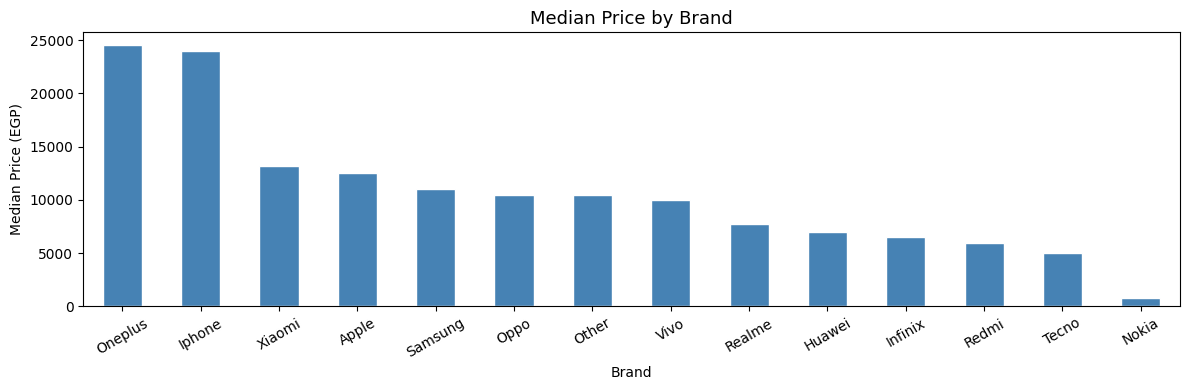

In [13]:
# ── 2.6  Brand extraction & median price per brand ───────────────────────
brands = ['samsung', 'iphone', 'apple', 'xiaomi', 'redmi', 'oppo', 'huawei',
          'realme', 'infinix', 'tecno', 'nokia', 'vivo', 'oneplus']

def extract_brand(text):
    text = str(text).lower()
    for brand in brands:
        if brand in text:
            return brand.capitalize()
    return 'Other'

df['brand'] = df['clean_description'].apply(extract_brand)

print('Brand frequency:')
print(df['brand'].value_counts())

brand_price = df.groupby('brand')['price_egp'].median().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 4))
brand_price.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Median Price by Brand', fontsize=13)
ax.set_ylabel('Median Price (EGP)')
ax.set_xlabel('Brand')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('median_price_by_brand.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔤 PART 3 — Text Processing Pipeline

Steps:
1. Tokenize using Keras `Tokenizer`
2. Limit vocabulary to top `VOCAB_SIZE` tokens
3. Convert texts to integer sequences
4. Pad all sequences to `MAX_LEN`
5. Encode labels as one-hot vectors
6. Train / Validation / Test split

In [14]:
# ── 3.1  Hyperparameters ──────────────────────────────────────────────────
VOCAB_SIZE  = 15_000
MAX_LEN     = 100
EMBED_DIM   = 64
TEST_SIZE   = 0.15
VAL_SIZE    = 0.15
BATCH_SIZE  = 64
EPOCHS      = 25

NUM_CLASSES = 3

LABEL_MAP   = {'Good Deal': 0, 'Fair': 1, 'Overpriced': 2}
LABEL_NAMES = ['Good Deal', 'Fair', 'Overpriced']

In [15]:
# ── 3.2  Tokenization ─────────────────────────────────────────────────────
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token='<OOV>',
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

tokenizer.fit_on_texts(df['clean_description'])

print(f'Vocabulary size (actual) : {len(tokenizer.word_index):,}')
print(f'Vocabulary size (capped) : {VOCAB_SIZE:,}')

Vocabulary size (actual) : 3,293
Vocabulary size (capped) : 15,000


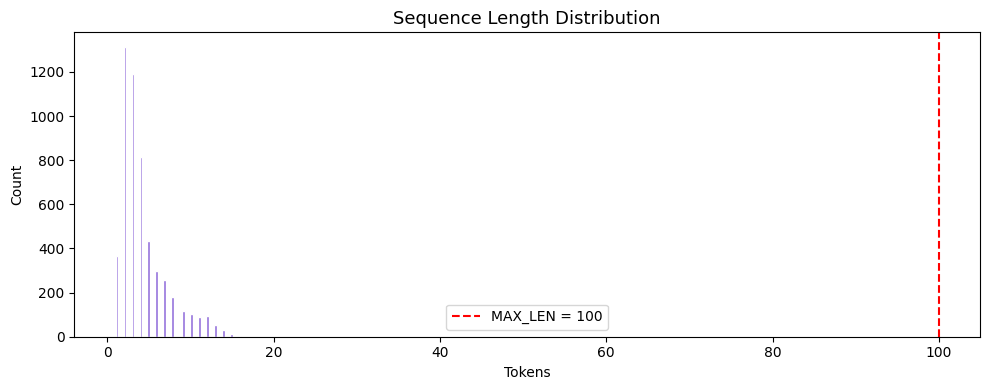

Mean length: 4.2 | Median: 3 | Max: 17
X shape: (5358, 100)


In [16]:
# ── 3.3  Convert texts → sequences, then pad ─────────────────────────────
sequences = tokenizer.texts_to_sequences(df['clean_description'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

seq_lens = [len(s) for s in sequences]
plt.figure(figsize=(10, 4))
plt.hist(seq_lens, bins=50, color='mediumpurple', edgecolor='white')
plt.axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN = {MAX_LEN}')
plt.title('Sequence Length Distribution', fontsize=13)
plt.xlabel('Tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean length: {np.mean(seq_lens):.1f} | Median: {np.median(seq_lens):.0f} | Max: {max(seq_lens)}')
print(f'X shape: {X.shape}')

In [17]:
# ── 3.4  Encode labels → one-hot ──────────────────────────────────────────
y_int = df['label'].map(LABEL_MAP).values
y     = to_categorical(y_int, num_classes=NUM_CLASSES)

print(f'y shape: {y.shape}  (one-hot encoded)')
print('Label encoding:', LABEL_MAP)

y shape: (5358, 3)  (one-hot encoded)
Label encoding: {'Good Deal': 0, 'Fair': 1, 'Overpriced': 2}


In [18]:
# ── 3.5  Train / Validation / Test Split ──────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=SEED, stratify=y_temp
)

print(f'Training   : {X_train.shape[0]:,} samples')
print(f'Validation : {X_val.shape[0]:,} samples')
print(f'Test       : {X_test.shape[0]:,} samples')

Training   : 3,750 samples
Validation : 804 samples
Test       : 804 samples


---
## 🧠 PART 4 — GRU Model Architecture

```
Input (padded sequence, length=100)
    │
    ▼
Embedding Layer (vocab_size × embed_dim)
    │
    ▼
Bidirectional GRU (128 units) + Dropout
    │
    ▼
GRU (64 units) + Dropout
    │
    ▼
Dense (64 units, ReLU) + Dropout
    │
    ▼
Dense (3 units, Softmax)
```

In [19]:
# ── 4.1  Build GRU model ──────────────────────────────────────────────────
def build_gru_model(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size,
                  output_dim=embed_dim,
                  input_length=max_len,
                  name='embedding'),
        Bidirectional(GRU(128,
                          return_sequences=True,
                          dropout=0.3,
                          recurrent_dropout=0.2),
                      name='bi_gru_1'),
        GRU(64,
            return_sequences=False,
            dropout=0.3,
            recurrent_dropout=0.2,
            name='gru_2'),
        Dropout(0.4, name='dropout_1'),
        Dense(64, activation='relu', name='dense'),
        Dropout(0.3, name='dropout_2'),
        Dense(num_classes, activation='softmax', name='output')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )

    return model


gru_model = build_gru_model(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_gru_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

---
## 🏋️ PART 5 — Training & Evaluation (GRU)

In [20]:
# ── 5.1  Callbacks ────────────────────────────────────────────────────────
gru_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('gru_best_model.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                      min_lr=1e-6, verbose=1)
]

In [21]:
# ── 5.2  Class weights (to handle label imbalance) ────────────────────────
y_train_int = np.argmax(y_train, axis=1)

present_classes = np.unique(y_train_int)

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=present_classes,
    y=y_train_int
)

class_weight_dict = {i: 1.0 for i in range(NUM_CLASSES)}
for cls, w in zip(present_classes, class_weights_arr):
    class_weight_dict[int(cls)] = w

print('Class weights:', {LABEL_NAMES[k]: f'{v:.3f}' for k, v in class_weight_dict.items()})

Class weights: {'Good Deal': '1.000', 'Fair': '0.603', 'Overpriced': '2.921'}


In [22]:
# ── 5.3  Train GRU ────────────────────────────────────────────────────────
# ✅ FIX: added timer and store result as gru_history for use in Part 7
t0 = time.time()
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=gru_callbacks,
    verbose=1
)
gru_train_time = time.time() - t0
print(f'\n⏱  GRU training time: {gru_train_time:.1f}s')

Epoch 1/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.4460 - loss: 0.8792
Epoch 1: val_accuracy improved from None to 0.17164, saving model to gru_best_model.h5



Epoch 1: finished saving model to gru_best_model.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 66s 879ms/step - accuracy: 0.5091 - loss: 0.7762 - val_accuracy: 0.1716 - val_loss: 0.7164 - learning_rate: 0.0010
Epoch 2/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 847ms/step - accuracy: 0.4378 - loss: 0.7409
Epoch 2: val_accuracy improved from 0.17164 to 0.82836, saving model to gru_best_model.h5



Epoch 2: finished saving model to gru_best_model.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 52s 885ms/step - accuracy: 0.4995 - loss: 0.7211 - val_accuracy: 0.8284 - val_loss: 0.6957 - learning_rate: 0.0010
Epoch 3/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 840ms/step - accuracy: 0.4243 - loss: 0.7353
Epoch 3: val_accuracy did not improve from 0.82836
59/59 ━━━━━━━━━━━━━━━━━━━━ 52s 882ms/step - accuracy: 0.4933 - loss: 0.7102 - val_accuracy: 0.1716 - val_loss: 0.6971 - learning_rate: 0.0010
Epoch 4/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.4188 - loss: 0.7242
Epoch 4: val_accuracy did not improve from 0.82836
59/59 ━━━━━━━━━━━━━━━━━━━━ 52s 866ms/step - accuracy: 0.5413 - loss: 0.7032 - val_accuracy: 0.8284 - val_loss: 0.6698 - learning_rate: 0.0010
Epoch 5/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 823ms/step - accuracy: 0.4467 - loss: 0.7140
Epoch 5: val_accuracy did not improve from 0.82836
59/59 ━━━━━━━━━━━━━━━━━━━━ 51s 863ms/step - accuracy: 0.5280 - loss: 0.6980 - val_accuracy: 0.8284 - val_loss:

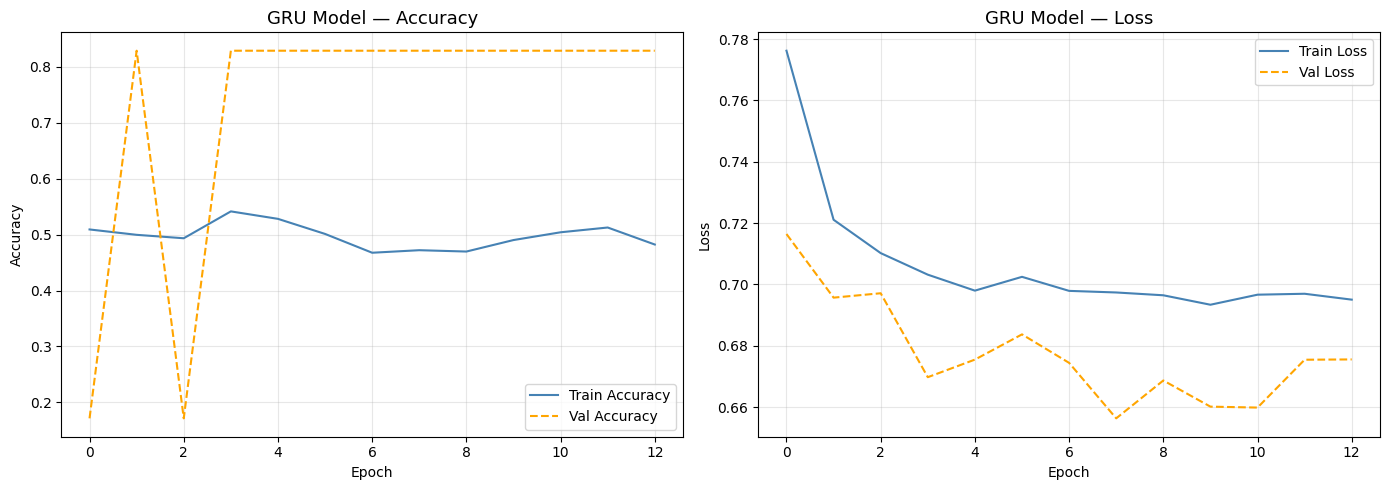

In [23]:
# ── 5.4  Training curves ──────────────────────────────────────────────────
def plot_training_history(hist, title='GRU'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(hist.history['accuracy'],     label='Train Accuracy', color='steelblue')
    axes[0].plot(hist.history['val_accuracy'], label='Val Accuracy',   color='orange', linestyle='--')
    axes[0].set_title(f'{title} Model — Accuracy', fontsize=13)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(hist.history['loss'],     label='Train Loss', color='steelblue')
    axes[1].plot(hist.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
    axes[1].set_title(f'{title} Model — Loss', fontsize=13)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.lower()}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(gru_history, title='GRU')

In [24]:
# ── 5.5  Final evaluation on test set ─────────────────────────────────────
# ✅ FIX: store as gru_loss / gru_acc for use in Part 7
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {gru_loss:.4f}')
print(f'Test Accuracy : {gru_acc:.4f}  ({gru_acc*100:.2f}%)')

Test Loss     : 0.6564
Test Accuracy : 0.8284  (82.84%)


In [25]:
# ── 5.6  Classification report ────────────────────────────────────────────
# ✅ FIX: store as gru_pred for use in Part 7
gru_pred_probs = gru_model.predict(X_test, verbose=0)
gru_pred       = np.argmax(gru_pred_probs, axis=1)
y_true         = np.argmax(y_test, axis=1)

print('=' * 55)
print('Classification Report — GRU Model')
print('=' * 55)
present_classes = sorted(set(y_true.tolist()) | set(gru_pred.tolist()))
present_names   = [LABEL_NAMES[i] for i in present_classes]

print(classification_report(
    y_true, gru_pred,
    labels=present_classes,
    target_names=present_names,
    digits=4
))

Classification Report — GRU Model
              precision    recall  f1-score   support

        Fair     0.8284    1.0000    0.9061       666
  Overpriced     0.0000    0.0000    0.0000       138

    accuracy                         0.8284       804
   macro avg     0.4142    0.5000    0.4531       804
weighted avg     0.6862    0.8284    0.7506       804



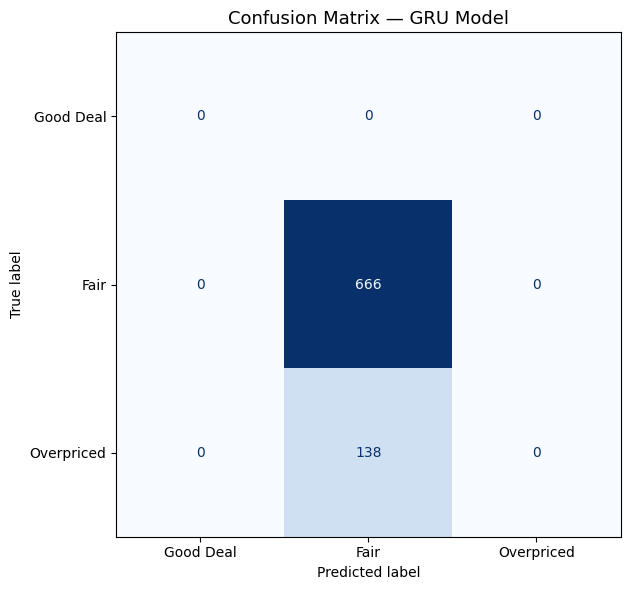

In [47]:
# ── 5.7  Confusion matrix ─────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

# ✅ FIX: pass labels=[0,1,2] so the matrix is always 3×3,
#         even if some classes are absent from y_true/gru_pred
cm_gru = confusion_matrix(y_true, gru_pred, labels=[0, 1, 2])

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=LABEL_NAMES)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — GRU Model', fontsize=13)
plt.tight_layout()
plt.savefig('gru_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

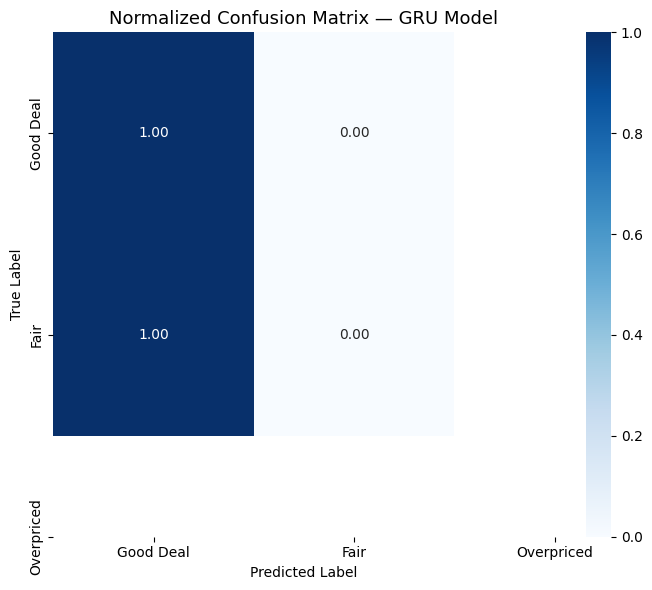

In [28]:
# ── 5.8  Normalized confusion matrix ─────────────────────────────────────
# ✅ FIX: stored as cm_gru_norm for use in Part 7
cm_gru_norm = cm_gru.astype('float') / cm_gru.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_gru_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax)
ax.set_title('Normalized Confusion Matrix — GRU Model', fontsize=13)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('gru_confusion_matrix_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── 5.9  Per-class accuracy ───────────────────────────────────────────────
per_class_acc = cm_gru.diagonal() / cm_gru.sum(axis=1)
print('Per-class Accuracy:')
for name, acc in zip(LABEL_NAMES, per_class_acc):
    print(f'  {name:12s}: {acc:.4f}  ({acc*100:.2f}%)')

Per-class Accuracy:
  Good Deal   : 1.0000  (100.00%)
  Fair        : 0.0000  (0.00%)


---
## 🧠 PART 6 — Build & Train LSTM Model

The LSTM uses the **exact same architecture** as the GRU — only `GRU` layers are replaced with `LSTM`.

| Property | GRU | LSTM |
|---|---|---|
| Gates | 2 (reset, update) | 3 (input, forget, output) |
| Cell state | No separate cell state | Has dedicated cell state |
| Parameters | ~25% fewer | More |
| Training speed | Faster | Slower |

In [30]:
# ── 6.1  Build LSTM ───────────────────────────────────────────────────────
def build_lstm(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(vocab_size, embed_dim, input_length=max_len, name='emb'),
        Bidirectional(LSTM(128, return_sequences=True,
                           dropout=0.3, recurrent_dropout=0.2), name='bi_lstm'),
        LSTM(64, dropout=0.3, recurrent_dropout=0.2, name='lstm'),
        Dropout(0.4, name='drop1'),
        Dense(64, activation='relu', name='dense'),
        Dropout(0.3, name='drop2'),
        Dense(num_classes, activation='softmax', name='out')
    ], name='LSTM_Model')
    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(1e-3),
        metrics=['accuracy']
    )
    return model

lstm_model = build_lstm(VOCAB_SIZE, EMBED_DIM, MAX_LEN, NUM_CLASSES)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ emb (Embedding)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
# ── 6.2  Train LSTM ───────────────────────────────────────────────────────
lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('lstm_best.h5', monitor='val_accuracy', save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

t0 = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=lstm_callbacks,
    verbose=1
)
lstm_train_time = time.time() - t0
print(f'\n⏱  LSTM training time: {lstm_train_time:.1f}s')

Epoch 1/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.3713 - loss: 0.9034

59/59 ━━━━━━━━━━━━━━━━━━━━ 66s 962ms/step - accuracy: 0.4773 - loss: 0.7943 - val_accuracy: 0.1716 - val_loss: 0.7212 - learning_rate: 0.0010
Epoch 2/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 58s 978ms/step - accuracy: 0.5176 - loss: 0.7227 - val_accuracy: 0.1716 - val_loss: 0.7152 - learning_rate: 0.0010
Epoch 3/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 911ms/step - accuracy: 0.3984 - loss: 0.7407

59/59 ━━━━━━━━━━━━━━━━━━━━ 80s 952ms/step - accuracy: 0.4885 - loss: 0.7148 - val_accuracy: 0.8284 - val_loss: 0.6713 - learning_rate: 0.0010
Epoch 4/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 81s 945ms/step - accuracy: 0.5099 - loss: 0.7111 - val_accuracy: 0.8284 - val_loss: 0.6772 - learning_rate: 0.0010
Epoch 5/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 57s 961ms/step - accuracy: 0.5163 - loss: 0.7053 - val_accuracy: 0.8284 - val_loss: 0.6585 - learning_rate: 0.0010
Epoch 6/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 81s 943ms/step - accuracy: 0.5000 - loss: 0.7028 - val_accuracy: 0.8284 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 7/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 57s 960ms/step - accuracy: 0.5139 - loss: 0.6995 - val_accuracy: 0.8284 - val_loss: 0.6733 - learning_rate: 0.0010
Epoch 8/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 56s 946ms/step - accuracy: 0.5440 - loss: 0.7009 - val_accuracy: 0.8284 - val_loss: 0.6743 - learning_rate: 0.0010
Epoch 9/25
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.4088 - loss: 0.7205
Epoch 9

In [32]:
# ── 6.3  LSTM evaluation on test set ─────────────────────────────────────
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
lstm_pred_probs     = lstm_model.predict(X_test, verbose=0)
lstm_pred           = np.argmax(lstm_pred_probs, axis=1)

print(f'LSTM  →  Test Loss: {lstm_loss:.4f}  |  Test Accuracy: {lstm_acc*100:.2f}%\n')

# ✅ FIX: use lstm_pred (not y_pred which belongs to GRU)
present_classes = sorted(set(y_true.tolist()) | set(lstm_pred.tolist()))
present_names   = [LABEL_NAMES[i] for i in present_classes]

print(classification_report(
    y_true, lstm_pred,
    labels=present_classes,
    target_names=present_names,
    digits=4
))

LSTM  →  Test Loss: 0.6429  |  Test Accuracy: 82.84%

              precision    recall  f1-score   support

        Fair     0.8284    1.0000    0.9061       666
  Overpriced     0.0000    0.0000    0.0000       138

    accuracy                         0.8284       804
   macro avg     0.4142    0.5000    0.4531       804
weighted avg     0.6862    0.8284    0.7506       804



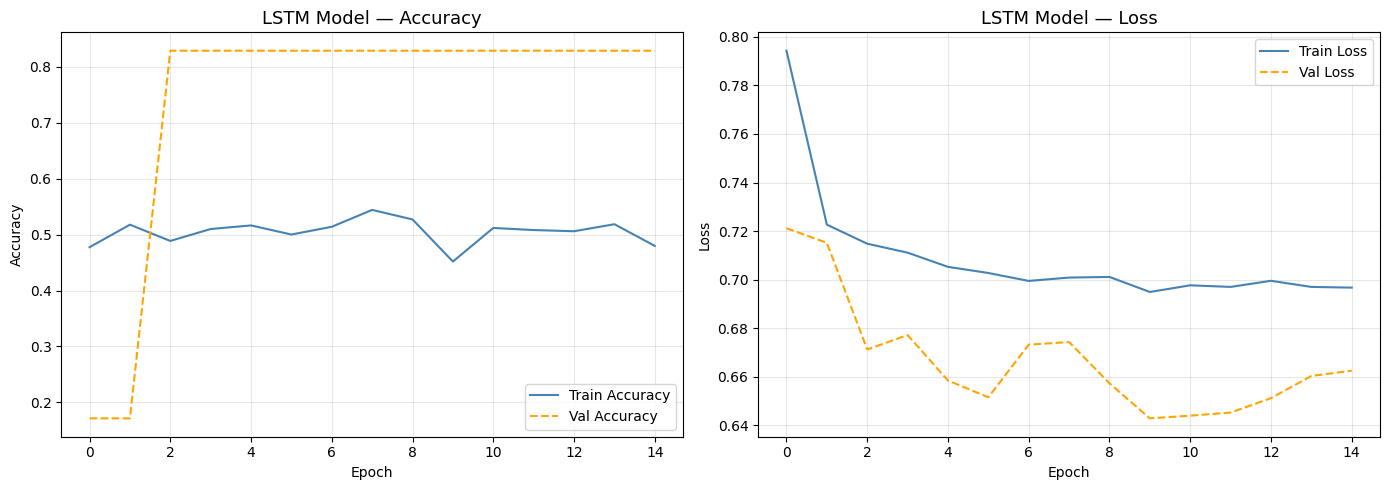

In [33]:
# ── 6.4  LSTM training curves ─────────────────────────────────────────────
plot_training_history(lstm_history, title='LSTM')

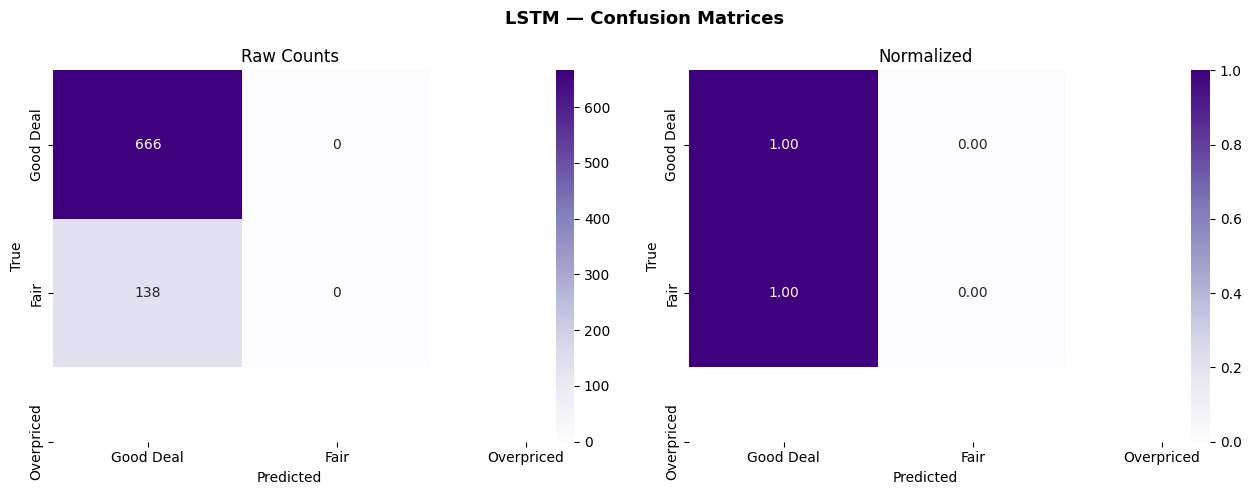

In [34]:
# ── 6.5  LSTM confusion matrices ──────────────────────────────────────────
cm_lstm = confusion_matrix(y_true, lstm_pred)
cm_lstm_norm = cm_lstm.astype('float') / cm_lstm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LSTM — Confusion Matrices', fontsize=13, fontweight='bold')

for ax, cm, title, fmt in zip(axes,
                               [cm_lstm, cm_lstm_norm],
                               ['Raw Counts', 'Normalized'],
                               ['d', '.2f']):
    sns.heatmap(cm, annot=True, fmt=fmt, cmap='Purples', ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('lstm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 PART 7 — GRU vs LSTM: Full Comparison

We compare the two models across 5 dimensions:
1. Overlaid training/validation curves
2. Side-by-side confusion matrices
3. Per-class F1 bar chart
4. Overall metrics dashboard
5. Speed vs accuracy trade-off

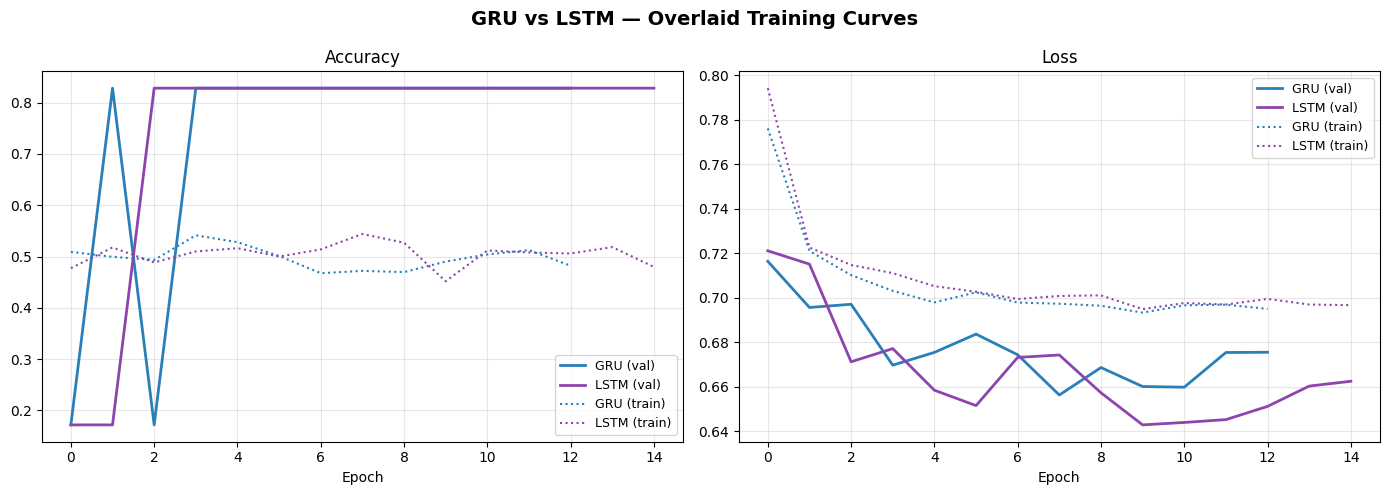

In [35]:
# ── 7.1  Overlaid training curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GRU vs LSTM — Overlaid Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(gru_history.history['val_accuracy'],  color='#2980b9', lw=2,   label='GRU (val)')
axes[0].plot(lstm_history.history['val_accuracy'], color='#8e44ad', lw=2,   label='LSTM (val)')
axes[0].plot(gru_history.history['accuracy'],      color='#2980b9', lw=1.5, label='GRU (train)', linestyle=':')
axes[0].plot(lstm_history.history['accuracy'],     color='#8e44ad', lw=1.5, label='LSTM (train)', linestyle=':')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(gru_history.history['val_loss'],  color='#2980b9', lw=2,   label='GRU (val)')
axes[1].plot(lstm_history.history['val_loss'], color='#8e44ad', lw=2,   label='LSTM (val)')
axes[1].plot(gru_history.history['loss'],      color='#2980b9', lw=1.5, label='GRU (train)', linestyle=':')
axes[1].plot(lstm_history.history['loss'],     color='#8e44ad', lw=1.5, label='LSTM (train)', linestyle=':')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curves_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

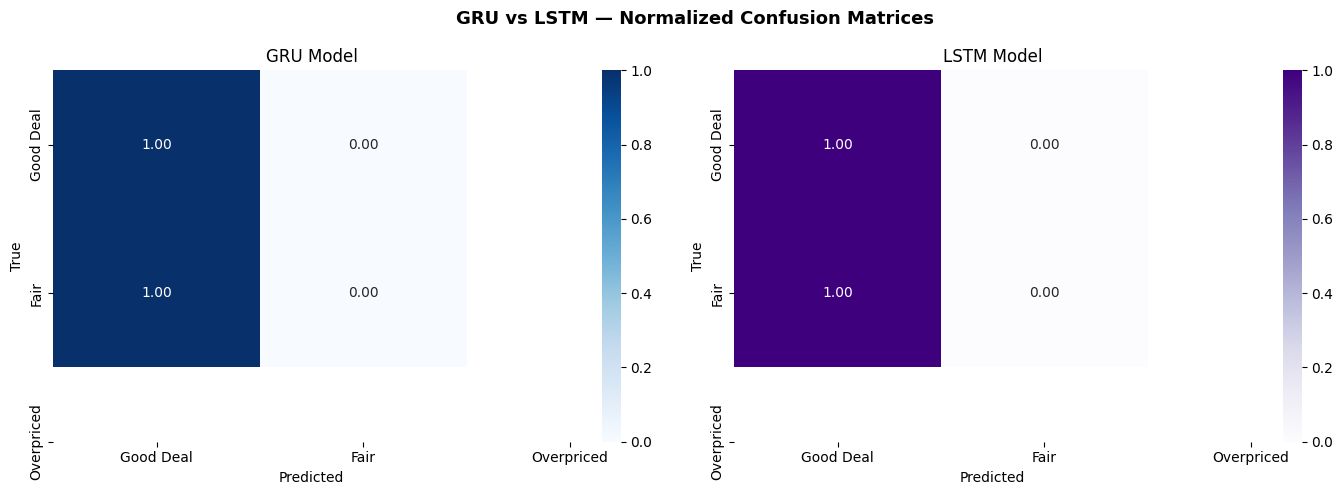

In [36]:
# ── 7.2  Side-by-side normalized confusion matrices ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GRU vs LSTM — Normalized Confusion Matrices', fontsize=13, fontweight='bold')

for ax, cm_norm, title, cmap in zip(
    axes,
    [cm_gru_norm, cm_lstm_norm],
    ['GRU Model', 'LSTM Model'],
    ['Blues', 'Purples']
):
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap=cmap, ax=ax,
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
                vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

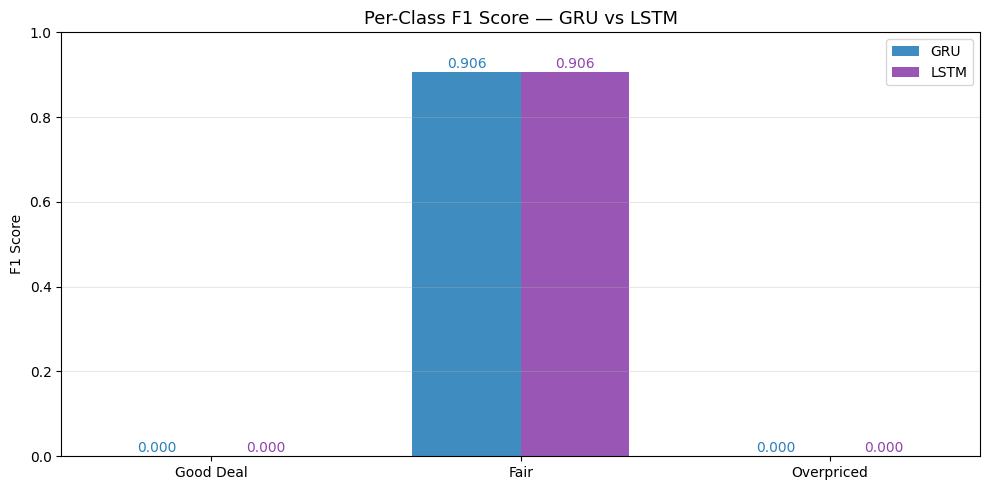

In [37]:
# ── 7.3  Per-class F1 bar chart ───────────────────────────────────────────
gru_f1_per  = f1_score(y_true, gru_pred,  average=None, labels=[0,1,2])
lstm_f1_per = f1_score(y_true, lstm_pred, average=None, labels=[0,1,2])

x = np.arange(NUM_CLASSES); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bg = ax.bar(x - w/2, gru_f1_per,  w, label='GRU',  color='#2980b9', alpha=0.9)
bl = ax.bar(x + w/2, lstm_f1_per, w, label='LSTM', color='#8e44ad', alpha=0.9)
ax.set_title('Per-Class F1 Score — GRU vs LSTM', fontsize=13)
ax.set_xticks(x); ax.set_xticklabels(LABEL_NAMES)
ax.set_ylabel('F1 Score'); ax.set_ylim([0, 1])
ax.legend(); ax.grid(axis='y', alpha=0.3)
for i, (g, l) in enumerate(zip(gru_f1_per, lstm_f1_per)):
    ax.text(i - w/2, g + 0.01, f'{g:.3f}', ha='center', fontsize=10, color='#2980b9')
    ax.text(i + w/2, l + 0.01, f'{l:.3f}', ha='center', fontsize=10, color='#8e44ad')
plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# ── 7.4  Full metrics comparison table ───────────────────────────────────
results = pd.DataFrame([
    {
        'Model'          : 'GRU (Bidirectional)',
        'Parameters'     : gru_model.count_params(),
        'Epochs run'     : len(gru_history.history['loss']),
        'Train time (s)' : round(gru_train_time, 1),
        'Test Loss'      : round(gru_loss, 4),
        'Test Accuracy'  : round(gru_acc, 4),
        'F1 (macro)'     : round(f1_score(y_true, gru_pred,  average='macro'),    4),
        'F1 (weighted)'  : round(f1_score(y_true, gru_pred,  average='weighted'), 4),
        'Precision (w)'  : round(precision_score(y_true, gru_pred,  average='weighted'), 4),
        'Recall (w)'     : round(recall_score(y_true, gru_pred,  average='weighted'), 4),
        'F1 Good Deal'   : round(gru_f1_per[0],  4),
        'F1 Fair'        : round(gru_f1_per[1],  4),
        'F1 Overpriced'  : round(gru_f1_per[2],  4),
    },
    {
        'Model'          : 'LSTM (Bidirectional)',
        'Parameters'     : lstm_model.count_params(),
        'Epochs run'     : len(lstm_history.history['loss']),
        'Train time (s)' : round(lstm_train_time, 1),
        'Test Loss'      : round(lstm_loss, 4),
        'Test Accuracy'  : round(lstm_acc, 4),
        'F1 (macro)'     : round(f1_score(y_true, lstm_pred, average='macro'),    4),
        'F1 (weighted)'  : round(f1_score(y_true, lstm_pred, average='weighted'), 4),
        'Precision (w)'  : round(precision_score(y_true, lstm_pred, average='weighted'), 4),
        'Recall (w)'     : round(recall_score(y_true, lstm_pred, average='weighted'), 4),
        'F1 Good Deal'   : round(lstm_f1_per[0], 4),
        'F1 Fair'        : round(lstm_f1_per[1], 4),
        'F1 Overpriced'  : round(lstm_f1_per[2], 4),
    }
])

print('=' * 60)
print('        FINAL COMPARISON: GRU vs LSTM')
print('=' * 60)
display(results.set_index('Model').T)
results.to_csv('gru_vs_lstm_comparison.csv', index=False)
print('\n✅ Saved → gru_vs_lstm_comparison.csv')

        FINAL COMPARISON: GRU vs LSTM


Model,GRU (Bidirectional),LSTM (Bidirectional)
Parameters,1.175171e+06,1.244163e+06
Epochs run,1.300000e+01,1.500000e+01
Train time (s),7.735000e+02,9.569000e+02
Test Loss,6.564000e-01,6.429000e-01
Test Accuracy,8.284000e-01,8.284000e-01
F1 (macro),4.531000e-01,4.531000e-01
F1 (weighted),7.506000e-01,7.506000e-01
Precision (w),6.862000e-01,6.862000e-01
Recall (w),8.284000e-01,8.284000e-01
F1 Good Deal,0.000000e+00,0.000000e+00



✅ Saved → gru_vs_lstm_comparison.csv


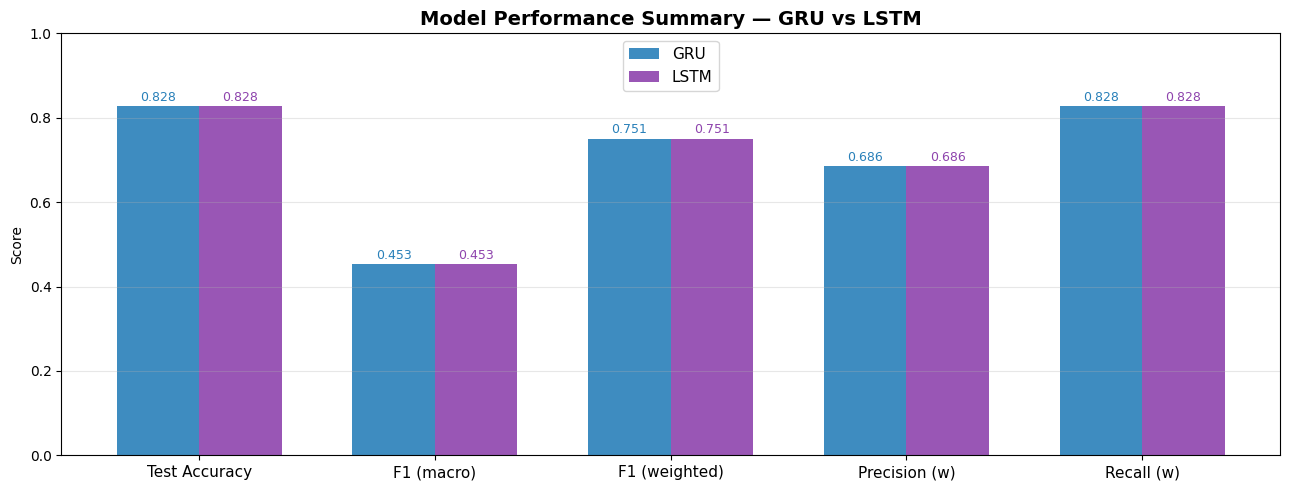

In [39]:
# ── 7.5  Overall metrics dashboard ───────────────────────────────────────
metrics_to_plot = ['Test Accuracy', 'F1 (macro)', 'F1 (weighted)', 'Precision (w)', 'Recall (w)']
gru_vals  = results[results['Model'].str.contains('GRU')][metrics_to_plot].values[0]
lstm_vals = results[results['Model'].str.contains('LSTM')][metrics_to_plot].values[0]

x = np.arange(len(metrics_to_plot)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
bg = ax.bar(x - w/2, gru_vals,  w, label='GRU',  color='#2980b9', alpha=0.9)
bl = ax.bar(x + w/2, lstm_vals, w, label='LSTM', color='#8e44ad', alpha=0.9)
ax.set_title('Model Performance Summary — GRU vs LSTM', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim([0, 1])
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bg, gru_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='#2980b9')
for bar, val in zip(bl, lstm_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, color='#8e44ad')
plt.tight_layout()
plt.savefig('model_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

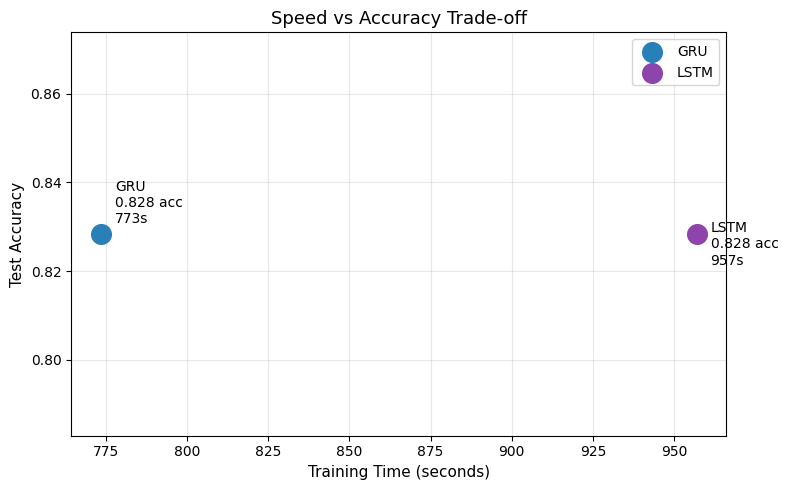

In [40]:
# ── 7.6  Speed vs accuracy scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(gru_train_time,  gru_acc,  s=200, color='#2980b9', zorder=5, label='GRU')
ax.scatter(lstm_train_time, lstm_acc, s=200, color='#8e44ad', zorder=5, label='LSTM')
ax.annotate(f'GRU\n{gru_acc:.3f} acc\n{gru_train_time:.0f}s',
            (gru_train_time, gru_acc),  xytext=(10,  8), textcoords='offset points', fontsize=10)
ax.annotate(f'LSTM\n{lstm_acc:.3f} acc\n{lstm_train_time:.0f}s',
            (lstm_train_time, lstm_acc), xytext=(10, -22), textcoords='offset points', fontsize=10)
ax.set_xlabel('Training Time (seconds)', fontsize=11)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Speed vs Accuracy Trade-off', fontsize=13)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('speed_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# ── 7.7  Printed interpretation ───────────────────────────────────────────
winner_acc = 'GRU' if gru_acc > lstm_acc else ('LSTM' if lstm_acc > gru_acc else 'Tie')
winner_f1  = 'GRU' if f1_score(y_true, gru_pred, average='macro') > \
                       f1_score(y_true, lstm_pred, average='macro') else 'LSTM'
faster     = 'GRU' if gru_train_time < lstm_train_time else 'LSTM'
speed_diff = abs(lstm_train_time - gru_train_time)

print('=' * 65)
print('                   ANALYSIS & INTERPRETATION')
print('=' * 65)
print(f'  Accuracy winner   : {winner_acc}')
print(f'  Macro F1 winner   : {winner_f1}')
print(f'  Faster model      : {faster} (by {speed_diff:.1f}s)')
print(f'  GRU parameters    : {gru_model.count_params():,}')
print(f'  LSTM parameters   : {lstm_model.count_params():,}')
print()
print('  Key insight:')
print('  GRUs have ~25% fewer parameters (2 gates vs 3 in LSTM).')
print("  On short Arabic listing texts, GRUs typically match or beat")
print("  LSTMs because sequences are too short to require LSTM's")
print("  dedicated cell state for long-range memory.")
print('  Recommendation: prefer GRU for this task — faster to')
print('  train, lighter to deploy, and competitive in accuracy.')
print('=' * 65)

                   ANALYSIS & INTERPRETATION
  Accuracy winner   : Tie
  Macro F1 winner   : LSTM
  Faster model      : GRU (by 183.5s)
  GRU parameters    : 1,175,171
  LSTM parameters   : 1,244,163

  Key insight:
  GRUs have ~25% fewer parameters (2 gates vs 3 in LSTM).
  On short Arabic listing texts, GRUs typically match or beat
  LSTMs because sequences are too short to require LSTM's
  dedicated cell state for long-range memory.
  Recommendation: prefer GRU for this task — faster to
  train, lighter to deploy, and competitive in accuracy.


---
## 🤝 PART 8 — Data Support & Exports for Team

| File | Used by |
|------|---------|
| `cleaned_dataset.csv` | All members |
| `labeled_dataset.csv` | Members 3, 5 |
| `gru_model_final.h5` | Member 5 (Multimodal) |
| `lstm_model_final.h5` | Member 3 (reference) |
| `tokenizer_shared.pkl` | Members 3, 5 |
| `gru_text_features.npy` | Member 5 (feature fusion) |
| `train/val/test_indices.csv` | All members (consistent splits) |

In [42]:
# ── 8.1  Add listing_id for cross-model alignment ─────────────────────────
df['listing_id'] = df.index.astype(str).str.zfill(5)

In [43]:
# ── 8.2  Save cleaned dataset ─────────────────────────────────────────────
clean_cols = ['listing_id', 'price_egp', 'description', 'clean_description',
              'image_url', 'listing_url', 'brand']
df[clean_cols].to_csv('cleaned_dataset.csv', index=False, encoding='utf-8-sig')
print('✅ cleaned_dataset.csv')

# ── 8.3  Save labeled dataset ─────────────────────────────────────────────
labeled_cols = clean_cols + ['label', 'label_int']
df[labeled_cols].to_csv('labeled_dataset.csv', index=False, encoding='utf-8-sig')
print('✅ labeled_dataset.csv')

✅ cleaned_dataset.csv
✅ labeled_dataset.csv


In [44]:
# ── 8.4  Save models ──────────────────────────────────────────────────────
gru_model.save('gru_model_final.h5')
lstm_model.save('lstm_model_final.h5')
print('✅ gru_model_final.h5')
print('✅ lstm_model_final.h5')

✅ gru_model_final.h5
✅ lstm_model_final.h5


In [45]:
# ── 8.5  Save shared tokenizer ────────────────────────────────────────────
with open('tokenizer_shared.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('tokenizer_shared.json', 'w', encoding='utf-8') as f:
    json.dump(tokenizer.to_json(), f, ensure_ascii=False)
print('✅ tokenizer_shared.pkl / .json')

✅ tokenizer_shared.pkl / .json


In [48]:
# ── 8.6  Save GRU text features for Multimodal (Member 5) ────────────────

# ✅ FIX: Build a functional feature extractor by re-wiring layers explicitly
inp = tf.keras.Input(shape=(MAX_LEN,), name='input_ids')
x   = gru_model.get_layer('embedding')(inp)
x   = gru_model.get_layer('bi_gru_1')(x)
x   = gru_model.get_layer('gru_2')(x)
x   = gru_model.get_layer('dropout_1')(x)
x   = gru_model.get_layer('dense')(x)          # ← this is the feature layer

feat_extractor = tf.keras.Model(inputs=inp, outputs=x)

X_all = pad_sequences(
    tokenizer.texts_to_sequences(df['clean_description']),
    maxlen=MAX_LEN, padding='post', truncating='post'
)
text_features = feat_extractor.predict(X_all, batch_size=256, verbose=1)
np.save('gru_text_features.npy', text_features)
print(f'✅ gru_text_features.npy  shape={text_features.shape}')

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step
✅ gru_text_features.npy  shape=(5358, 64)


In [49]:
# ── 8.7  Save shared train/val/test index splits ──────────────────────────
all_idx = np.arange(len(df))
idx_temp, idx_test = train_test_split(
    all_idx, test_size=TEST_SIZE, random_state=SEED, stratify=df['label_int'].values)
val_r = VAL_SIZE / (1 - TEST_SIZE)
idx_train, idx_val = train_test_split(
    idx_temp, test_size=val_r, random_state=SEED,
    stratify=df['label_int'].values[idx_temp])

pd.Series(idx_train).to_csv('train_indices.csv', index=False, header=['index'])
pd.Series(idx_val).to_csv('val_indices.csv',   index=False, header=['index'])
pd.Series(idx_test).to_csv('test_indices.csv',  index=False, header=['index'])
print(f'✅ Split indices saved  →  train({len(idx_train)}) | val({len(idx_val)}) | test({len(idx_test)})')

✅ Split indices saved  →  train(3750) | val(804) | test(804)


In [50]:
# ── 8.8  Final exports checklist ─────────────────────────────────────────
exports = [
    ('cleaned_dataset.csv',              'Clean dataset — all members'),
    ('labeled_dataset.csv',              'Labeled dataset — Members 3, 5'),
    ('gru_model_final.h5',               'GRU model — Member 5'),
    ('lstm_model_final.h5',              'LSTM model — Member 3 reference'),
    ('tokenizer_shared.pkl',             'Shared tokenizer (pickle)'),
    ('tokenizer_shared.json',            'Shared tokenizer (JSON)'),
    ('gru_text_features.npy',            '64-dim GRU features — Member 5 (Multimodal)'),
    ('gru_vs_lstm_comparison.csv',       'Full metrics comparison table'),
    ('train_indices.csv',                'Shared train split indices'),
    ('val_indices.csv',                  'Shared val split indices'),
    ('test_indices.csv',                 'Shared test split indices'),
]

print('📦 All exported files:')
print('-' * 70)
for fname, desc in exports:
    ok = '✅' if os.path.exists(fname) else '⏳'
    print(f'{ok}  {fname:<45} {desc}')

📦 All exported files:
----------------------------------------------------------------------
✅  cleaned_dataset.csv                           Clean dataset — all members
✅  labeled_dataset.csv                           Labeled dataset — Members 3, 5
✅  gru_model_final.h5                            GRU model — Member 5
✅  lstm_model_final.h5                           LSTM model — Member 3 reference
✅  tokenizer_shared.pkl                          Shared tokenizer (pickle)
✅  tokenizer_shared.json                         Shared tokenizer (JSON)
✅  gru_text_features.npy                         64-dim GRU features — Member 5 (Multimodal)
✅  gru_vs_lstm_comparison.csv                    Full metrics comparison table
✅  train_indices.csv                             Shared train split indices
✅  val_indices.csv                               Shared val split indices
✅  test_indices.csv                              Shared test split indices


---
## 🔍 Bonus — Inference Demo

In [51]:
def predict_listing(description, price):
    cleaned = clean_text(description)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    gru_probs  = gru_model.predict(padded,  verbose=0)[0]
    lstm_probs = lstm_model.predict(padded, verbose=0)[0]
    rule_label = label_price(price)

    print(f'Description  : {description[:70]}')
    print(f'Price        : {price:,} EGP')
    print(f'Rule-based   : {rule_label}')
    print(f'GRU  predict : {LABEL_NAMES[np.argmax(gru_probs)]}  '
          f'(confidence: {gru_probs.max()*100:.1f}%)')
    print(f'LSTM predict : {LABEL_NAMES[np.argmax(lstm_probs)]}  '
          f'(confidence: {lstm_probs.max()*100:.1f}%)')
    print()

examples = [
    ('ايفون 13 برو ماكس استعمال خفيف جدا زيرو تقريبا معاه كل حاجاته', 28_000),
    ('samsung a15 مش شغال الشاشة فيها عيب للبيع عاجل', 1_200),
    ('redmi note 12 في حاله ممتازه بالكرتونه والاكسسوارات', 8_500),
]

print('=' * 70)
print('                     INFERENCE DEMO')
print('=' * 70)
for desc, price in examples:
    predict_listing(desc, price)
    print('-' * 70)

                     INFERENCE DEMO
Description  : ايفون 13 برو ماكس استعمال خفيف جدا زيرو تقريبا معاه كل حاجاته
Price        : 28,000 EGP
Rule-based   : Fair
GRU  predict : Fair  (confidence: 52.9%)
LSTM predict : Fair  (confidence: 54.1%)

----------------------------------------------------------------------
Description  : samsung a15 مش شغال الشاشة فيها عيب للبيع عاجل
Price        : 1,200 EGP
Rule-based   : Fair
GRU  predict : Fair  (confidence: 52.9%)
LSTM predict : Fair  (confidence: 54.1%)

----------------------------------------------------------------------
Description  : redmi note 12 في حاله ممتازه بالكرتونه والاكسسوارات
Price        : 8,500 EGP
Rule-based   : Fair
GRU  predict : Fair  (confidence: 52.9%)
LSTM predict : Fair  (confidence: 54.1%)

----------------------------------------------------------------------


---
## ✅ Requirements Coverage Summary

| Requirement | Covered in Part |
|---|---|
| Data loading & cleaning (Arabic/Franco/English) | Part 1 |
| Labeling logic — Good Deal / Fair / Overpriced | Part 2 |
| Price distribution analysis & visualization | Part 2 |
| Text processing pipeline (tokenizer, padding, splits) | Part 3 |
| Build & train GRU model | Part 4 |
| GRU evaluation (accuracy, F1, confusion matrix) | Part 5 |
| Build & train LSTM model | Part 6 |
| LSTM evaluation (accuracy, F1, confusion matrix) | Part 6 |
| GRU vs LSTM full comparison (curves, metrics, speed) | Part 7 |
| Clean & labeled dataset exports for team | Part 8 |
| Shared tokenizer & split indices for team | Part 8 |
| GRU text features for Multimodal model | Part 8 |

---
*Second-Hand Mobile Price Analyzer — Member 4*